# 1. Title and Purpose

This is **Notebook 2 of 2** in the Argentina Portfolio Risk Intelligence Pipeline. It assumes that `merval_analysis.ipynb` has already populated the required processed tables in BigQuery.

## Academic purpose
- convert processed market features into portfolio-level analytics
- document a transparent risk-return methodology that can be reviewed cell by cell
- generate simulation-based downside metrics for reporting and dashboard use
- publish run-specific analytics tables that can later be standardized and tested in dbt

## Execution dependency
- Notebook 1 writes `raw_market` and `processed_market`
- this notebook reads `processed_market` and writes `analytics_market`
- dbt then integrates both notebook outputs into documented and tested serving models

## Replicability controls used here
- all outputs are stamped with a stable `portfolio_id`, a run-specific `run_id`, and `ingestion_timestamp`
- simulation results are reproducible because a fixed `RANDOM_SEED` is used
- the same 252-trading-day convention is used as in Notebook 1 and the dbt layer


# 2. Imports and Configuration

The next code cell centralizes the main controls for replication: warehouse identifiers, the portfolio definition, simulation horizon, initial portfolio value, and the Monte Carlo random seed.

For a professor or reviewer, this is the quickest place to confirm exactly which scenario was run.


In [1]:
import os
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from google.api_core.exceptions import NotFound
from google.cloud import bigquery

# Global annualization convention shared with Notebook 1 and the dbt models.
TRADING_DAYS = 252

PROJECT_ID = "bigdata-financeargentina"
LOCATION = "US"

RAW_DATASET = "raw_market"
PROCESSED_DATASET = "processed_market"
ANALYTICS_DATASET = "analytics_market"

# Stable portfolio identifier for cross-run comparison plus run-specific audit fields.
PORTFOLIO_ID = "argentina_demo_portfolio"
RUN_ID = str(uuid.uuid4())
INGESTION_TIMESTAMP = datetime.now(timezone.utc)
INCREMENTAL_MODE = False  # Set to False for a clean slate on each run.

USER_PORTFOLIO = {
    "GGAL.BA": 0.25,
    "YPFD.BA": 0.25,
    "PAMP.BA": 0.20,
    "BMA.BA": 0.15,
    "CEPU.BA": 0.15
}

INITIAL_PORTFOLIO_VALUE = 10000
NUM_SIMULATIONS = 10000
SIMULATION_DAYS = TRADING_DAYS
RANDOM_SEED = 42


# 3. BigQuery Connection

This notebook reads processed inputs from `processed_market` and writes run-based analytics outputs to `analytics_market`.

## Authentication notes
- for local development, use Application Default Credentials with `gcloud auth application-default login`
- for service-account execution, set `GOOGLE_APPLICATION_CREDENTIALS`
- do not hardcode credentials in the notebook or repository

If client creation fails, verify read access to `processed_market` and write access to `analytics_market`.


In [2]:
client = bigquery.Client(project=PROJECT_ID, location=LOCATION)


def table_ref(dataset, table):
    return f"{PROJECT_ID}.{dataset}.{table}"

# 4. Helper Functions

The helper functions keep the notebook readable and make each methodological choice explicit rather than hidden inside a single procedural block.

They cover four concerns:
- warehouse access and rerun-safe uploads
- annualization and drawdown formulas
- safe arithmetic and input validation
- basic table-existence checks before analytics begin


In [3]:
def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query in BigQuery and return a pandas DataFrame."""
    job = client.query(sql)
    return job.result().to_dataframe(create_bqstorage_client=False)


def table_exists(dataset: str, table: str) -> bool:
    """Return True if a BigQuery table exists, otherwise False."""
    try:
        client.get_table(table_ref(dataset, table))
        return True
    except NotFound:
        return False


def load_dataframe_to_bq(df, dataset, table, write_disposition="WRITE_TRUNCATE"):
    """Upload a DataFrame to BigQuery with rerun-safe append behavior."""
    if df is None or df.empty:
        raise ValueError(f"Refusing to upload an empty DataFrame to {dataset}.{table}")

    target_table = table_ref(dataset, table)
    job_config = bigquery.LoadJobConfig(write_disposition=write_disposition)

    try:
        existing_table = client.get_table(target_table)
    except NotFound:
        existing_table = None

    if write_disposition == "WRITE_APPEND" and existing_table is not None:
        if "run_id" in df.columns:
            run_ids = df["run_id"].dropna().astype(str).unique().tolist()
            if run_ids:
                delete_sql = f"""
                DELETE FROM `{target_table}`
                WHERE run_id IN UNNEST(@run_ids)
                """
                delete_job_config = bigquery.QueryJobConfig(
                    query_parameters=[
                        bigquery.ArrayQueryParameter("run_ids", "STRING", run_ids)
                    ]
                )
                client.query(delete_sql, job_config=delete_job_config).result()
                print(f"Removed existing rows for {len(run_ids)} run_id value(s) from {target_table}")

        existing_columns = {field.name for field in existing_table.schema}
        new_columns = [column for column in df.columns if column not in existing_columns]
        if new_columns:
            job_config.schema_update_options = [
                bigquery.SchemaUpdateOption.ALLOW_FIELD_ADDITION,
                bigquery.SchemaUpdateOption.ALLOW_FIELD_RELAXATION,
            ]
            print(f"Schema evolution enabled for {target_table}. Adding columns: {', '.join(new_columns)}")

    job = client.load_table_from_dataframe(df, target_table, job_config=job_config)
    job.result()
    print(f"Uploaded {len(df):,} rows to {target_table} with {write_disposition}")


def annualize_return(mean_daily_log_return):
    """Convert average daily log return to annualized log return using 252 trading days."""
    if pd.isna(mean_daily_log_return):
        return np.nan
    return mean_daily_log_return * TRADING_DAYS


def annualize_volatility(daily_std):
    """Convert daily standard deviation to annualized volatility."""
    if pd.isna(daily_std):
        return np.nan
    return daily_std * np.sqrt(TRADING_DAYS)


def calculate_max_drawdown(return_series):
    """Calculate maximum drawdown from a daily log-return series."""
    if return_series is None:
        return np.nan

    clean_returns = pd.Series(return_series).dropna()
    if clean_returns.empty:
        return np.nan

    cumulative = np.exp(clean_returns.cumsum())
    running_peak = cumulative.cummax()
    drawdown = cumulative / running_peak - 1
    return drawdown.min()


def validate_portfolio_weights(user_portfolio):
    """Validate that portfolio weights are non-negative and sum to 1."""
    if not user_portfolio:
        raise ValueError("USER_PORTFOLIO is empty. Please provide at least one ticker and weight.")

    weights = pd.Series(user_portfolio, dtype="float64")

    if (weights < 0).any():
        negative_tickers = weights[weights < 0].index.tolist()
        raise ValueError(f"Negative weights are not allowed: {negative_tickers}")

    total_weight = weights.sum()
    if not np.isclose(total_weight, 1.0, atol=1e-8):
        raise ValueError(f"Portfolio weights must sum to 1. Current sum: {total_weight:.8f}")

    return weights


def safe_divide(numerator, denominator):
    """Safely divide two numbers and return NaN when denominator is zero or null."""
    if denominator is None or pd.isna(denominator) or np.isclose(denominator, 0):
        return np.nan
    return numerator / denominator


# 5. Validate BigQuery Input Tables

Before computing analytics, the notebook confirms that the required processed tables from Notebook 1 are already available in BigQuery.

This creates a clean dependency boundary between the two notebooks and prevents partially successful analytics runs caused by missing upstream inputs.


In [4]:
required_tables = [
    ("processed_market", "asset_returns"),
    ("processed_market", "factor_returns"),
    ("processed_market", "stock_metrics"),
    ("processed_market", "beta_metrics"),
    ("processed_market", "correlation_matrix_long")
]

missing_tables = []

for dataset, table in required_tables:
    exists = table_exists(dataset, table)
    status = "OK" if exists else "MISSING"
    print(f"[{status}] {table_ref(dataset, table)}")
    if not exists:
        missing_tables.append(table_ref(dataset, table))

if missing_tables:
    raise FileNotFoundError(
        "The following required BigQuery tables are missing from the ETL stage:\n"
        + "\n".join(missing_tables)
    )

[OK] bigdata-financeargentina.processed_market.asset_returns
[OK] bigdata-financeargentina.processed_market.factor_returns
[OK] bigdata-financeargentina.processed_market.stock_metrics
[OK] bigdata-financeargentina.processed_market.beta_metrics
[OK] bigdata-financeargentina.processed_market.correlation_matrix_long


# 6. Load Processed Tables from BigQuery

This section reads the processed-layer tables into pandas and applies a small set of defensive clean-up steps.

## Why these checks matter
- parse `date` fields consistently
- normalize identifier columns to string
- coerce numeric metrics to numeric types
- drop exact duplicates defensively
- sort for deterministic downstream calculations

These steps improve repeatability when warehouse tables have been appended across multiple notebook runs.


In [5]:
asset_returns = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'asset_returns')}`")
factor_returns = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'factor_returns')}`")
stock_metrics = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'stock_metrics')}`")
beta_metrics = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'beta_metrics')}`")
correlation_matrix_long = run_query(f"SELECT * FROM `{table_ref(PROCESSED_DATASET, 'correlation_matrix_long')}`")

for df_name, df in {
    "asset_returns": asset_returns,
    "factor_returns": factor_returns,
    "stock_metrics": stock_metrics,
    "beta_metrics": beta_metrics,
    "correlation_matrix_long": correlation_matrix_long,
}.items():
    if df.empty:
        raise ValueError(f"{df_name} was loaded from BigQuery but is empty.")

if "date" in asset_returns.columns:
    asset_returns["date"] = pd.to_datetime(asset_returns["date"], utc=False, errors="coerce")
if "date" in factor_returns.columns:
    factor_returns["date"] = pd.to_datetime(factor_returns["date"], utc=False, errors="coerce")

# Normalize identifier fields to strings so joins and filters remain stable across source systems.
for col in ["ticker", "ticker_1", "ticker_2"]:
    if col in asset_returns.columns:
        asset_returns[col] = asset_returns[col].astype(str)
    if col in stock_metrics.columns:
        stock_metrics[col] = stock_metrics[col].astype(str)
    if col in beta_metrics.columns:
        beta_metrics[col] = beta_metrics[col].astype(str)
    if col in correlation_matrix_long.columns:
        correlation_matrix_long[col] = correlation_matrix_long[col].astype(str)

for numeric_col in ["log_return", "simple_return", "usd_adjusted_return", "excess_return", "risk_free_daily"]:
    if numeric_col in asset_returns.columns:
        asset_returns[numeric_col] = pd.to_numeric(asset_returns[numeric_col], errors="coerce")

for numeric_col in ["factor_return", "risk_free_daily", "merval_return", "eem_return", "fx_return"]:
    if numeric_col in factor_returns.columns:
        factor_returns[numeric_col] = pd.to_numeric(factor_returns[numeric_col], errors="coerce")

# Defensive de-duplication helps keep reruns deterministic if upstream tables were appended multiple times.
asset_returns = asset_returns.drop_duplicates().sort_values([c for c in ["date", "ticker"] if c in asset_returns.columns]).reset_index(drop=True)
factor_returns = factor_returns.drop_duplicates().sort_values([c for c in ["date"] if c in factor_returns.columns]).reset_index(drop=True)
stock_metrics = stock_metrics.drop_duplicates().reset_index(drop=True)
beta_metrics = beta_metrics.drop_duplicates().reset_index(drop=True)
correlation_matrix_long = correlation_matrix_long.drop_duplicates().reset_index(drop=True)

print("Loaded tables successfully:")
print(f"- asset_returns: {asset_returns.shape}")
print(f"- factor_returns: {factor_returns.shape}")
print(f"- stock_metrics: {stock_metrics.shape}")
print(f"- beta_metrics: {beta_metrics.shape}")
print(f"- correlation_matrix_long: {correlation_matrix_long.shape}")


Loaded tables successfully:
- asset_returns: (9745, 14)
- factor_returns: (10057, 4)
- stock_metrics: (5, 14)
- beta_metrics: (5, 3)
- correlation_matrix_long: (25, 3)


# 7. Build Returns Wide Table

Portfolio analytics and simulation are easier to compute from a wide return matrix with one row per date and one column per ticker.

## Design choices
- `log_return` is kept as the canonical return measure for consistency with Notebook 1
- `pivot_table(..., aggfunc='mean')` is used instead of `pivot` so duplicate `date` and `ticker` rows do not break the notebook
- tickers with too little history are removed before covariance estimation
- selected portfolio names must share an overlapping observation window so all portfolio metrics use the same sample


In [6]:
required_asset_columns = {"date", "ticker", "log_return"}
missing_asset_columns = required_asset_columns - set(asset_returns.columns)
if missing_asset_columns:
    raise ValueError(f"asset_returns is missing required columns: {sorted(missing_asset_columns)}")

returns_wide = asset_returns.pivot_table(
    index="date",
    columns="ticker",
    values="log_return",
    aggfunc="mean"
).sort_index()

# Remove columns that contain no usable return history at all.
returns_wide = returns_wide.dropna(axis=1, how="all")

if returns_wide.empty:
    raise ValueError("returns_wide is empty after pivoting. Check processed_market.asset_returns.")

# Very short histories produce unstable covariance estimates, so enforce a minimum sample size.
min_required_observations = max(30, SIMULATION_DAYS // 4)
observation_counts = returns_wide.notna().sum().sort_values(ascending=False)
valid_columns = observation_counts[observation_counts >= min_required_observations].index.tolist()
returns_wide = returns_wide[valid_columns]

if returns_wide.empty:
    raise ValueError(
        f"No tickers have at least {min_required_observations} observations, which is not enough for analytics."
    )

selected_tickers = list(USER_PORTFOLIO.keys())
missing_portfolio_tickers = sorted(set(selected_tickers) - set(returns_wide.columns))
if missing_portfolio_tickers:
    raise ValueError(
        "The following portfolio tickers are missing from returns_wide: "
        + ", ".join(missing_portfolio_tickers)
    )

print(f"returns_wide shape: {returns_wide.shape}")
print(f"Portfolio tickers available: {selected_tickers}")


returns_wide shape: (1949, 5)
Portfolio tickers available: ['GGAL.BA', 'YPFD.BA', 'PAMP.BA', 'BMA.BA', 'CEPU.BA']


# 8. User Portfolio Input Validation

This section validates the user-defined weights and creates the identifiers used in downstream tables.

## Identifier logic
- `portfolio_id` identifies the economic portfolio across runs
- `run_id` identifies one specific execution of the notebook

That separation is important for academic replicability because it allows repeated scenarios for the same portfolio to be compared over time.


In [7]:
weights = validate_portfolio_weights(USER_PORTFOLIO)

available_stock_tickers = set(stock_metrics["ticker"].astype(str)) if "ticker" in stock_metrics.columns else set()
missing_in_stock_metrics = sorted(set(weights.index) - available_stock_tickers)
if missing_in_stock_metrics:
    raise ValueError(
        "The following portfolio tickers are missing from processed_market.stock_metrics: "
        + ", ".join(missing_in_stock_metrics)
    )

portfolio_returns = returns_wide[weights.index.tolist()].copy()
# Restrict to dates where the full portfolio is observable so all metrics share one comparable sample.
portfolio_returns = portfolio_returns.dropna(how="any")

if portfolio_returns.empty:
    raise ValueError(
        "There is no overlapping return history for the selected portfolio tickers after aligning dates."
    )

portfolio_inputs = pd.DataFrame({
    "portfolio_id": PORTFOLIO_ID,
    "ticker": weights.index.astype(str),
    "weight": weights.values,
    "run_id": RUN_ID,
    "ingestion_timestamp": INGESTION_TIMESTAMP,
})

print(f"Portfolio ID: {PORTFOLIO_ID}")
print(f"Aligned portfolio return history shape: {portfolio_returns.shape}")
portfolio_inputs


Portfolio ID: argentina_demo_portfolio
Aligned portfolio return history shape: (1949, 5)


,portfolio_id,ticker,weight,run_id,ingestion_timestamp
0,argentina_demo_portfolio,GGAL.BA,0.25,69aaa09c-6bfa-4d10-859b-21324a44fa0f,2026-04-23 16:35:31.037870+00:00
1,argentina_demo_portfolio,YPFD.BA,0.25,69aaa09c-6bfa-4d10-859b-21324a44fa0f,2026-04-23 16:35:31.037870+00:00
2,argentina_demo_portfolio,PAMP.BA,0.20,69aaa09c-6bfa-4d10-859b-21324a44fa0f,2026-04-23 16:35:31.037870+00:00
3,argentina_demo_portfolio,BMA.BA,0.15,69aaa09c-6bfa-4d10-859b-21324a44fa0f,2026-04-23 16:35:31.037870+00:00
4,argentina_demo_portfolio,CEPU.BA,0.15,69aaa09c-6bfa-4d10-859b-21324a44fa0f,2026-04-23 16:35:31.037870+00:00


# 9. Portfolio Risk-Return Analytics

This section estimates historical, fixed-weight portfolio metrics from aligned daily log returns.

## Core formulas
- expected annual portfolio return: `mean(portfolio_log_return) * 252`
- annual volatility: `stddev(portfolio_log_return) * sqrt(252)`
- weighted Sharpe: `mean(portfolio_excess_return) * 252 / annual_volatility`
- concentration risk HHI: `sum(w_i^2)`
- diversification effect: `sum(w_i * sigma_i) - sigma_p`
- contribution to risk: derived from the covariance matrix, not from stand-alone volatilities alone

## Methodological notes
- returns are kept in log space for consistency with Notebook 1 and the dbt layer
- weighted betas are built from the stock-level beta estimates created upstream
- if a risk-free series is unavailable, the notebook falls back to a zero-rate assumption and prints a warning


In [8]:
mean_daily_returns = portfolio_returns.mean()
cov_daily = portfolio_returns.cov()

# Weighted sum of constituent log returns is the portfolio's daily log-return approximation.
portfolio_daily_returns = portfolio_returns @ weights

expected_portfolio_return = annualize_return(portfolio_daily_returns.mean())
portfolio_volatility = annualize_volatility(portfolio_daily_returns.std())
max_drawdown = calculate_max_drawdown(portfolio_daily_returns)

# Risk-free daily series can come from asset_returns or factor_returns depending on upstream design.
risk_free_series = None
if "risk_free_daily" in asset_returns.columns:
    risk_free_series = (
        asset_returns[["date", "risk_free_daily"]]
        .dropna(subset=["date"])
        .groupby("date", as_index=True)["risk_free_daily"]
        .mean()
    )
elif "risk_free_daily" in factor_returns.columns:
    risk_free_series = (
        factor_returns[["date", "risk_free_daily"]]
        .dropna(subset=["date"])
        .groupby("date", as_index=True)["risk_free_daily"]
        .mean()
    )

if risk_free_series is not None and not risk_free_series.empty:
    aligned_rf = risk_free_series.reindex(portfolio_daily_returns.index).ffill().fillna(0)
else:
    print("Warning: risk_free_daily not found in processed inputs. Defaulting to 0 for Sharpe ratio.")
    aligned_rf = pd.Series(0, index=portfolio_daily_returns.index, dtype="float64")

excess_portfolio_daily = portfolio_daily_returns - aligned_rf
weighted_sharpe = safe_divide(excess_portfolio_daily.mean() * TRADING_DAYS, portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS))

# Weighted betas are built from stock-level metrics if available.
def choose_beta_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

beta_merval_col = choose_beta_column(beta_metrics, ["beta_vs_merval", "beta_merval", "beta_to_merval"])
beta_eem_col = choose_beta_column(beta_metrics, ["beta_vs_eem", "beta_eem", "beta_to_eem"])

weighted_beta_merval = np.nan
weighted_beta_eem = np.nan

if "ticker" in beta_metrics.columns and beta_merval_col:
    beta_lookup = beta_metrics.drop_duplicates(subset=["ticker"]).set_index("ticker")
    weighted_beta_merval = float((weights * beta_lookup.reindex(weights.index)[beta_merval_col]).sum())
    if beta_eem_col:
        weighted_beta_eem = float((weights * beta_lookup.reindex(weights.index)[beta_eem_col]).sum())

# Concentration risk uses the Herfindahl-Hirschman Index (HHI).
concentration_risk_hhi = float((weights ** 2).sum())

# Diversification effect compares weighted average stand-alone volatility against portfolio volatility.
individual_vols = portfolio_returns.std() * np.sqrt(TRADING_DAYS)
weighted_average_asset_vol = float((weights * individual_vols).sum())
diversification_effect = weighted_average_asset_vol - portfolio_volatility

# Contribution to return is weight times annualized asset return.
asset_annual_returns = mean_daily_returns.apply(annualize_return)
contribution_to_return = weights * asset_annual_returns

# Contribution to risk uses marginal contribution implied by the covariance matrix.
portfolio_variance_daily = float(weights.T @ cov_daily.values @ weights)
portfolio_vol_daily = np.sqrt(portfolio_variance_daily)
if np.isclose(portfolio_vol_daily, 0):
    contribution_to_risk_pct = pd.Series(np.nan, index=weights.index)
else:
    marginal_contrib = cov_daily.values @ weights.values
    component_contrib = weights.values * marginal_contrib / portfolio_vol_daily
    contribution_to_risk_pct = pd.Series(
        component_contrib / component_contrib.sum(),
        index=weights.index,
        dtype="float64"
    )

portfolio_scenarios = pd.DataFrame([
    {
        "portfolio_id": PORTFOLIO_ID,
        "run_id": RUN_ID,
        "expected_portfolio_return": expected_portfolio_return,
        "portfolio_volatility": portfolio_volatility,
        "weighted_beta_merval": weighted_beta_merval,
        "weighted_beta_eem": weighted_beta_eem,
        "weighted_sharpe": weighted_sharpe,
        "max_drawdown": max_drawdown,
        "diversification_effect": diversification_effect,
        "concentration_risk_hhi": concentration_risk_hhi,
        "num_assets": int(len(weights)),
        "ingestion_timestamp": INGESTION_TIMESTAMP,
    }
])

portfolio_contributions = pd.DataFrame({
    "portfolio_id": PORTFOLIO_ID,
    "ticker": weights.index,
    "weight": weights.values,
    "contribution_to_return": contribution_to_return.values,
    "contribution_to_risk_pct": contribution_to_risk_pct.reindex(weights.index).values,
    "run_id": RUN_ID,
    "ingestion_timestamp": INGESTION_TIMESTAMP,
})

portfolio_scenarios


,portfolio_id,run_id,expected_portfolio_return,portfolio_volatility,weighted_beta_merval,weighted_beta_eem,weighted_sharpe,max_drawdown,diversification_effect,concentration_risk_hhi,num_assets,ingestion_timestamp
0,argentina_demo_portfolio,69aaa09c-6bfa-4d10-859b-21324a44fa0f,0.578421,0.536886,1.098257,0.864881,1.024266,-0.617671,0.068198,0.21,5,2026-04-23 16:35:31.037870+00:00


# 10. Monte Carlo Simulation

This section adds a forward-looking scenario layer by estimating a multivariate normal model from the historical constituent return matrix.

## Simulation assumptions
- the historical mean vector and covariance matrix are treated as stationary over the simulation horizon
- portfolio weights remain fixed during the simulation
- transaction costs, taxes, liquidity constraints, and rebalancing frictions are ignored
- the outputs are scenario-analysis tools, not forecasts

Because the notebook uses log returns, simulated wealth is reconstructed as:
`initial_value * exp(cumulative_simulated_log_return)`

## Summary metrics created
- mean, median, minimum, and maximum final portfolio value
- percentile bands
- probability of loss
- expected simulated return
- VaR 95 and CVaR 95


In [9]:
np.random.seed(RANDOM_SEED)

mean_daily_returns_array = mean_daily_returns.reindex(weights.index).values
cov_daily_matrix = cov_daily.reindex(index=weights.index, columns=weights.index).values

# Add a tiny diagonal jitter when covariance is numerically unstable.
cov_daily_matrix = cov_daily_matrix + np.eye(len(weights)) * 1e-12

simulated_daily_returns = np.random.multivariate_normal(
    mean=mean_daily_returns_array,
    cov=cov_daily_matrix,
    size=(NUM_SIMULATIONS, SIMULATION_DAYS)
)

portfolio_weight_array = weights.values.reshape(-1, 1)
simulated_portfolio_daily_returns = np.matmul(simulated_daily_returns, portfolio_weight_array).squeeze(-1)

# Because returns are simulated in log space, convert them back to wealth with exp(cumulative log return).
simulated_growth = np.exp(np.cumsum(simulated_portfolio_daily_returns, axis=1))
simulated_portfolio_values = INITIAL_PORTFOLIO_VALUE * simulated_growth
final_values = simulated_portfolio_values[:, -1]

# Store only a subset of paths for visualization to keep the warehouse footprint manageable.
paths_to_store = min(250, NUM_SIMULATIONS)
monte_carlo_paths = pd.DataFrame({
    "portfolio_id": PORTFOLIO_ID,
    "simulation_id": np.repeat(np.arange(paths_to_store), SIMULATION_DAYS),
    "day": np.tile(np.arange(1, SIMULATION_DAYS + 1), paths_to_store),
    "portfolio_value": simulated_portfolio_values[:paths_to_store].reshape(-1),
    "run_id": RUN_ID,
    "ingestion_timestamp": INGESTION_TIMESTAMP,
})

percentile_5 = np.percentile(final_values, 5)
percentile_25 = np.percentile(final_values, 25)
percentile_75 = np.percentile(final_values, 75)
percentile_95 = np.percentile(final_values, 95)
probability_of_loss = float(np.mean(final_values < INITIAL_PORTFOLIO_VALUE))
expected_return_simulated = float(np.mean(final_values / INITIAL_PORTFOLIO_VALUE - 1))
var_95 = float(INITIAL_PORTFOLIO_VALUE - percentile_5)
worst_5pct_values = final_values[final_values <= percentile_5]
cvar_95 = float(INITIAL_PORTFOLIO_VALUE - worst_5pct_values.mean()) if len(worst_5pct_values) > 0 else np.nan

monte_carlo_summary = pd.DataFrame([
    {
        "portfolio_id": PORTFOLIO_ID,
        "run_id": RUN_ID,
        "initial_value": INITIAL_PORTFOLIO_VALUE,
        "num_simulations": NUM_SIMULATIONS,
        "simulation_days": SIMULATION_DAYS,
        "mean_final_value": float(np.mean(final_values)),
        "median_final_value": float(np.median(final_values)),
        "min_final_value": float(np.min(final_values)),
        "max_final_value": float(np.max(final_values)),
        "percentile_5": float(percentile_5),
        "percentile_25": float(percentile_25),
        "percentile_75": float(percentile_75),
        "percentile_95": float(percentile_95),
        "probability_of_loss": probability_of_loss,
        "expected_return_simulated": expected_return_simulated,
        "var_95": var_95,
        "cvar_95": cvar_95,
        "ingestion_timestamp": INGESTION_TIMESTAMP,
    }
])

monte_carlo_summary


,portfolio_id,run_id,initial_value,num_simulations,simulation_days,mean_final_value,median_final_value,min_final_value,max_final_value,percentile_5,percentile_25,percentile_75,percentile_95,probability_of_loss,expected_return_simulated,var_95,cvar_95,ingestion_timestamp
0,argentina_demo_portfolio,69aaa09c-6bfa-4d10-859b-21324a44fa0f,10000,10000,252,20712.005851,18048.381809,2750.068142,141761.347516,7410.027925,12397.429408,25759.265996,43074.373584,0.1431,1.071201,2589.972075,3957.52736,2026-04-23 16:35:31.037870+00:00


# 11. Monte Carlo Visualizations

The visual outputs created here are designed to be directly reusable in the report or presentation.

Charts are saved under `outputs/charts/` so they remain available outside the notebook session, which helps with academic submission and review.


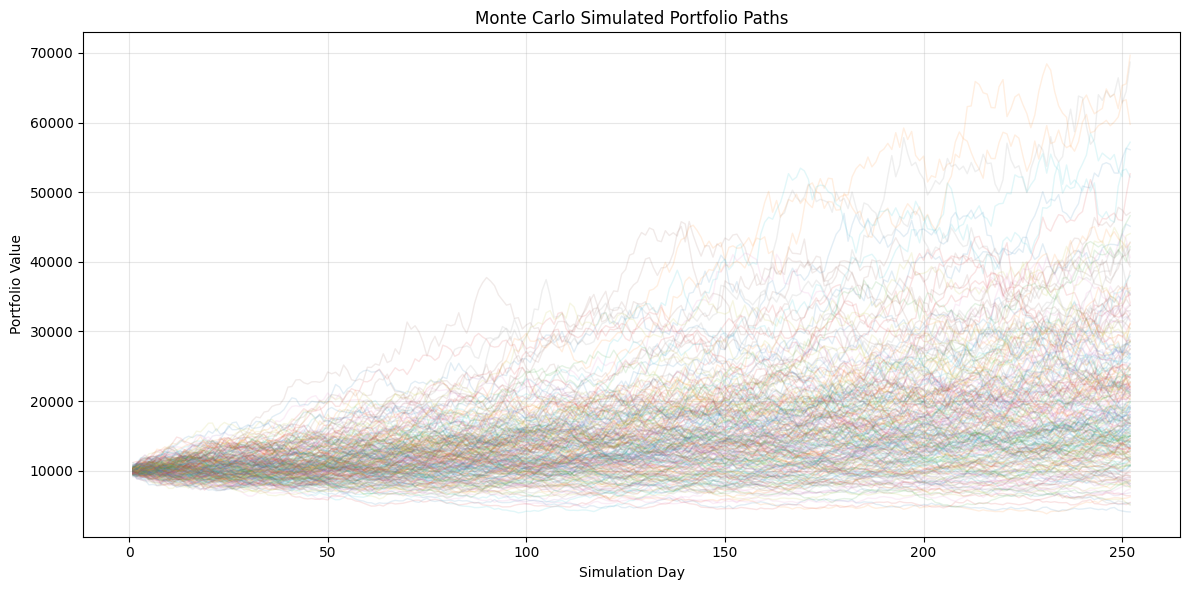

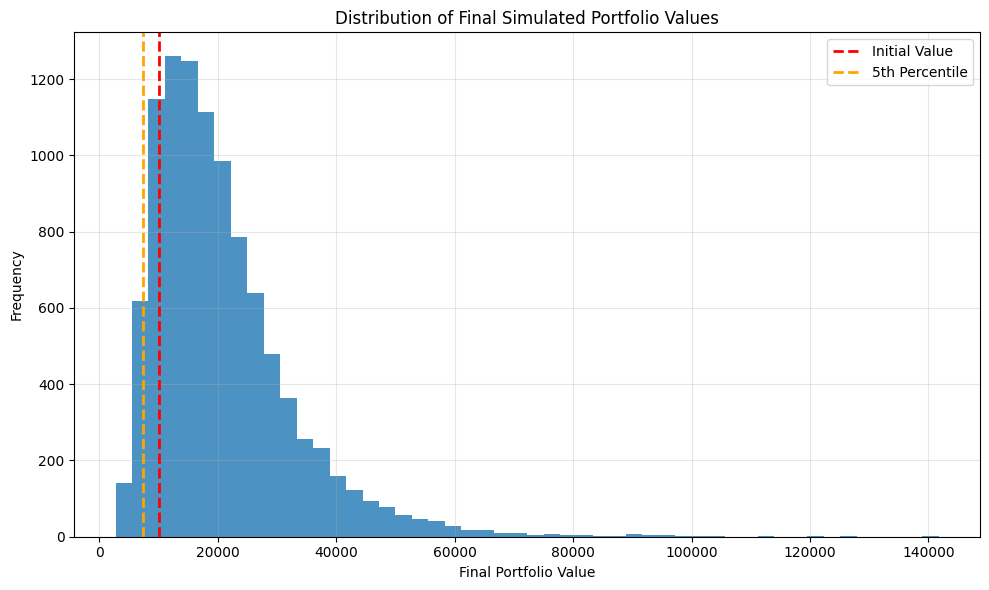

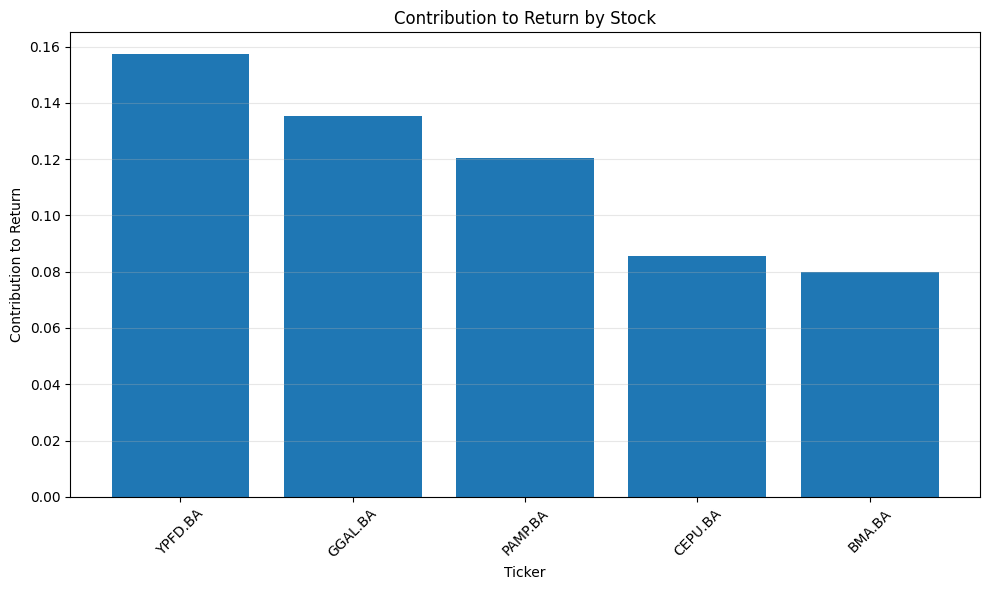

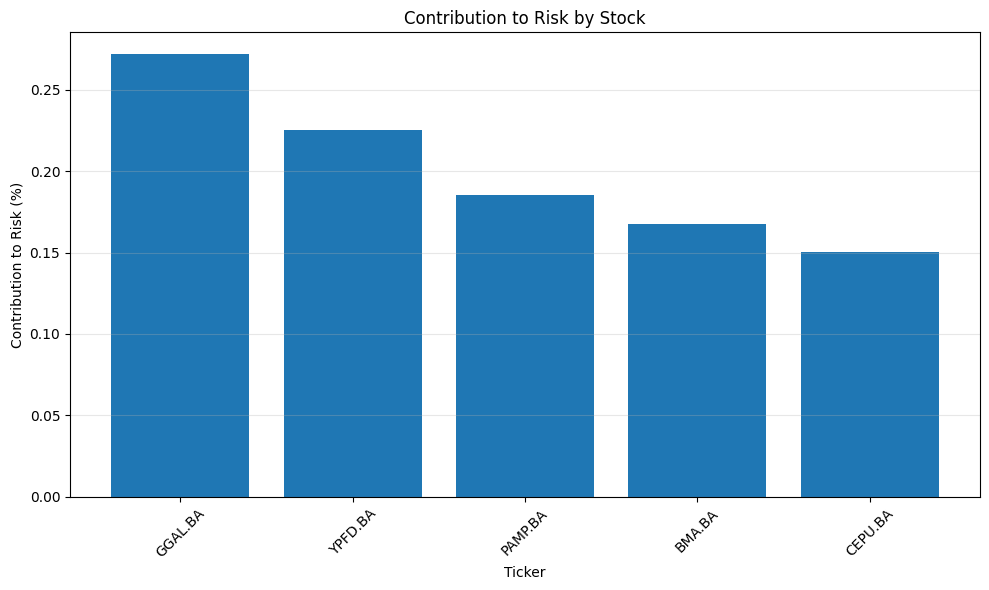

Charts saved to:
- outputs/charts/monte_carlo_paths.png
- outputs/charts/final_value_distribution.png
- outputs/charts/return_contribution.png
- outputs/charts/risk_contribution.png


In [10]:
output_dir = os.path.join("outputs", "charts")
os.makedirs(output_dir, exist_ok=True)

# 1. Simulated path subset for visualization.
plt.figure(figsize=(12, 6))
for sim_id, sim_df in monte_carlo_paths.groupby("simulation_id"):
    plt.plot(sim_df["day"], sim_df["portfolio_value"], alpha=0.12, linewidth=1)
plt.title("Monte Carlo Simulated Portfolio Paths")
plt.xlabel("Simulation Day")
plt.ylabel("Portfolio Value")
plt.grid(alpha=0.3)
paths_chart_path = os.path.join(output_dir, "monte_carlo_paths.png")
plt.tight_layout()
plt.savefig(paths_chart_path, dpi=150)
plt.show()

# 2. Histogram of final simulated values.
plt.figure(figsize=(10, 6))
plt.hist(final_values, bins=50, alpha=0.8)
plt.axvline(INITIAL_PORTFOLIO_VALUE, color="red", linestyle="--", linewidth=2, label="Initial Value")
plt.axvline(percentile_5, color="orange", linestyle="--", linewidth=2, label="5th Percentile")
plt.title("Distribution of Final Simulated Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
distribution_chart_path = os.path.join(output_dir, "final_value_distribution.png")
plt.tight_layout()
plt.savefig(distribution_chart_path, dpi=150)
plt.show()

# 3. Contribution to return by stock.
plot_return_contrib = portfolio_contributions.sort_values("contribution_to_return", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(plot_return_contrib["ticker"], plot_return_contrib["contribution_to_return"])
plt.title("Contribution to Return by Stock")
plt.xlabel("Ticker")
plt.ylabel("Contribution to Return")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
return_chart_path = os.path.join(output_dir, "return_contribution.png")
plt.tight_layout()
plt.savefig(return_chart_path, dpi=150)
plt.show()

# 4. Contribution to risk by stock.
plot_risk_contrib = portfolio_contributions.sort_values("contribution_to_risk_pct", ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(plot_risk_contrib["ticker"], plot_risk_contrib["contribution_to_risk_pct"])
plt.title("Contribution to Risk by Stock")
plt.xlabel("Ticker")
plt.ylabel("Contribution to Risk (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
risk_chart_path = os.path.join(output_dir, "risk_contribution.png")
plt.tight_layout()
plt.savefig(risk_chart_path, dpi=150)
plt.show()

print("Charts saved to:")
print(f"- {paths_chart_path}")
print(f"- {distribution_chart_path}")
print(f"- {return_chart_path}")
print(f"- {risk_chart_path}")

# 12. Portfolio Classification

The classification logic is intentionally heuristic and communication-oriented. It is meant to summarize the observed risk profile in plain language, not to act as a formal investor-suitability engine.

The stock ranking score is also transparent: it rewards return and Sharpe ratio, penalizes volatility and beta, and lightly rewards shallower drawdowns.


In [11]:
# Helper lookup functions let the notebook tolerate small upstream naming differences.
def choose_metric_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

vol_col = choose_metric_column(stock_metrics, ["volatility", "annual_volatility"])
sharpe_col = choose_metric_column(stock_metrics, ["sharpe_ratio", "annual_sharpe", "sharpe"])
mdd_col = choose_metric_column(stock_metrics, ["max_drawdown", "drawdown"])
stock_return_col = choose_metric_column(stock_metrics, ["average_return", "annual_return", "expected_return", "return_annualized"])

corr_fx_col = choose_metric_column(correlation_matrix_long, ["correlation", "correlation_value"])

fx_sensitive = False
fx_reason = ""
if corr_fx_col and {"ticker_1", "ticker_2"}.issubset(correlation_matrix_long.columns):
    fx_pairs = correlation_matrix_long[
        (
            correlation_matrix_long["ticker_1"].isin(weights.index)
            & correlation_matrix_long["ticker_2"].astype(str).str.contains("USD|FX|ARS", case=False, na=False)
        )
        |
        (
            correlation_matrix_long["ticker_2"].isin(weights.index)
            & correlation_matrix_long["ticker_1"].astype(str).str.contains("USD|FX|ARS", case=False, na=False)
        )
    ].copy()
    if not fx_pairs.empty:
        max_abs_fx_corr = fx_pairs[corr_fx_col].abs().max()
        if pd.notna(max_abs_fx_corr) and max_abs_fx_corr >= 0.50:
            fx_sensitive = True
            fx_reason = f"High observed FX correlation ({max_abs_fx_corr:.2f})."

if fx_sensitive and probability_of_loss >= 0.35:
    portfolio_type = "high-risk FX-sensitive"
    portfolio_type_reason = f"Portfolio shows elevated downside risk and currency sensitivity. {fx_reason}".strip()
elif portfolio_volatility <= 0.20 and (pd.isna(weighted_beta_merval) or weighted_beta_merval <= 0.90) and probability_of_loss <= 0.25:
    portfolio_type = "conservative"
    portfolio_type_reason = "Low volatility, contained beta exposure, and relatively low probability of capital loss."
elif portfolio_volatility >= 0.35 or (pd.notna(weighted_beta_merval) and weighted_beta_merval >= 1.20):
    portfolio_type = "aggressive"
    portfolio_type_reason = "High volatility and/or elevated market beta indicate stronger upside-downside swings."
else:
    portfolio_type = "balanced"
    portfolio_type_reason = "Portfolio sits between defensive and aggressive thresholds on volatility and beta."

portfolio_scenarios["portfolio_type"] = portfolio_type
portfolio_scenarios["portfolio_type_reason"] = portfolio_type_reason

# Build stock-level ranking view for the selected holdings only.
stock_rank_base = stock_metrics.copy()
stock_rank_base["ticker"] = stock_rank_base["ticker"].astype(str)
stock_rank_base = stock_rank_base[stock_rank_base["ticker"].isin(weights.index)].copy()

if beta_merval_col and "ticker" in beta_metrics.columns:
    beta_for_ranking = beta_metrics[["ticker", beta_merval_col]].drop_duplicates(subset=["ticker"])
    stock_rank_base = stock_rank_base.merge(beta_for_ranking, on="ticker", how="left")
    stock_rank_base = stock_rank_base.rename(columns={beta_merval_col: "beta_vs_merval"})
else:
    stock_rank_base["beta_vs_merval"] = np.nan

if vol_col and vol_col != "volatility":
    stock_rank_base = stock_rank_base.rename(columns={vol_col: "volatility"})
if sharpe_col and sharpe_col != "sharpe_ratio":
    stock_rank_base = stock_rank_base.rename(columns={sharpe_col: "sharpe_ratio"})
if mdd_col and mdd_col != "max_drawdown":
    stock_rank_base = stock_rank_base.rename(columns={mdd_col: "max_drawdown"})
if stock_return_col and stock_return_col != "annual_return":
    stock_rank_base = stock_rank_base.rename(columns={stock_return_col: "annual_return"})

for col in ["annual_return", "volatility", "beta_vs_merval", "sharpe_ratio", "max_drawdown"]:
    if col not in stock_rank_base.columns:
        stock_rank_base[col] = np.nan

# The ranking weights are heuristic and intentionally transparent for academic discussion.
stock_rank_base["ranking_score"] = (
    stock_rank_base["annual_return"].fillna(0) * 0.35
    + stock_rank_base["sharpe_ratio"].fillna(0) * 0.35
    - stock_rank_base["volatility"].fillna(0) * 0.15
    - stock_rank_base["beta_vs_merval"].fillna(0) * 0.10
    + stock_rank_base["max_drawdown"].fillna(0) * 0.05
)

stock_rank_base["portfolio_type"] = portfolio_type
stock_rank_base["justification"] = stock_rank_base.apply(
    lambda row: (
        f"Sharpe={row['sharpe_ratio']:.2f}, Vol={row['volatility']:.2f}, "
        f"Beta={row['beta_vs_merval']:.2f}, MaxDD={row['max_drawdown']:.2f}"
        if pd.notna(row["sharpe_ratio"]) and pd.notna(row["volatility"]) else
        "Ranking based on available processed return and risk metrics."
    ),
    axis=1
)
stock_rank_base["run_id"] = RUN_ID
stock_rank_base["ingestion_timestamp"] = INGESTION_TIMESTAMP

stock_rankings = stock_rank_base[[
    "ticker",
    "portfolio_type",
    "ranking_score",
    "volatility",
    "beta_vs_merval",
    "sharpe_ratio",
    "max_drawdown",
    "justification",
    "run_id",
    "ingestion_timestamp",
]].sort_values("ranking_score", ascending=False).reset_index(drop=True)

portfolio_scenarios[["portfolio_id", "portfolio_type", "portfolio_type_reason"]]


,portfolio_id,portfolio_type,portfolio_type_reason
0,argentina_demo_portfolio,aggressive,High volatility and/or elevated market beta in...


# 13. Upload Analytics Tables to BigQuery

This section publishes the run-specific analytics tables to `analytics_market`.

## Write strategy
- scenario and simulation tables use `WRITE_APPEND`
- the upload helper removes rows for the same `run_id` before append, so rerunning the notebook does not duplicate one execution
- replaceable documentation tables, such as the data dictionary, can still use `WRITE_TRUNCATE`


In [13]:
write_strategy = raw_write_mode = "WRITE_APPEND" if INCREMENTAL_MODE else "WRITE_TRUNCATE"

analytics_uploads = [
    (portfolio_inputs, ANALYTICS_DATASET, "portfolio_inputs", write_strategy),
    (portfolio_scenarios, ANALYTICS_DATASET, "portfolio_scenarios", write_strategy),
    (portfolio_contributions, ANALYTICS_DATASET, "portfolio_contributions", write_strategy),
    (monte_carlo_paths, ANALYTICS_DATASET, "monte_carlo_paths", write_strategy),
    (monte_carlo_summary, ANALYTICS_DATASET, "monte_carlo_summary", write_strategy),
    (stock_rankings, ANALYTICS_DATASET, "stock_rankings", write_strategy),
]

written_tables = []
for df, dataset, table, disposition in analytics_uploads:
    load_dataframe_to_bq(df, dataset, table, write_disposition=disposition)
    written_tables.append(table_ref(dataset, table))
    print(f"Confirmed upload -> {table_ref(dataset, table)}")


Uploaded 5 rows to bigdata-financeargentina.analytics_market.portfolio_inputs with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.portfolio_inputs
Uploaded 1 rows to bigdata-financeargentina.analytics_market.portfolio_scenarios with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.portfolio_scenarios
Uploaded 5 rows to bigdata-financeargentina.analytics_market.portfolio_contributions with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.portfolio_contributions
Uploaded 63,000 rows to bigdata-financeargentina.analytics_market.monte_carlo_paths with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.monte_carlo_paths
Uploaded 1 rows to bigdata-financeargentina.analytics_market.monte_carlo_summary with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.monte_carlo_summary
Uploaded 5 rows to bigdata-financeargentina.analytics_market.stock_rankings with W

# 14. Data Dictionary Generation

This section creates a tidy documentation table so downstream readers can understand what each published metric means and how it was produced.

That is especially useful in an academic setting because it turns the analytics tables into something that can be defended in a report or oral presentation without reopening every code cell.


In [14]:
data_dictionary_records = [
    {
        "table_name": "processed_market.asset_returns",
        "column_name": "log_return",
        "data_type": "FLOAT",
        "definition": "Natural log of the price relative between consecutive observations.",
        "transformation_logic": "Calculated as LN(price_t / price_t-1) after sorting by ticker and date.",
        "business_use": "Canonical return metric for risk modeling, correlation analysis, and simulation inputs."
    },
    {
        "table_name": "processed_market.asset_returns",
        "column_name": "usd_adjusted_return",
        "data_type": "FLOAT",
        "definition": "Daily stock return adjusted for ARS/USD currency movement.",
        "transformation_logic": "Calculated as stock log return minus USDARS log return.",
        "business_use": "Helps interpret local equity performance from a USD-based perspective."
    },
    {
        "table_name": "processed_market.asset_returns",
        "column_name": "excess_return",
        "data_type": "FLOAT",
        "definition": "Daily asset return net of the daily risk-free proxy.",
        "transformation_logic": "Calculated as log_return minus aligned risk_free_daily.",
        "business_use": "Supports Sharpe ratio and other risk-adjusted performance metrics."
    },
    {
        "table_name": "processed_market.beta_metrics",
        "column_name": "beta_vs_merval",
        "data_type": "FLOAT",
        "definition": "Sensitivity of stock return to MERVAL return.",
        "transformation_logic": "Estimated as the OLS slope of stock log return on MERVAL log return.",
        "business_use": "Measures local market systematic risk."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "volatility",
        "data_type": "FLOAT",
        "definition": "Annualized standard deviation of daily log returns.",
        "transformation_logic": "STDDEV(daily_log_return) multiplied by sqrt(252).",
        "business_use": "Primary stand-alone risk metric for ranking and classification."
    },
    {
        "table_name": "processed_market.stock_metrics",
        "column_name": "sharpe_ratio",
        "data_type": "FLOAT",
        "definition": "Risk-adjusted return relative to the risk-free proxy.",
        "transformation_logic": "Annualized excess return divided by annualized volatility.",
        "business_use": "Compares return quality across securities and portfolios."
    },
    {
        "table_name": "processed_market.correlation_matrix_long",
        "column_name": "correlation",
        "data_type": "FLOAT",
        "definition": "Pairwise linear correlation between two return series.",
        "transformation_logic": "Calculated from aligned daily return pairs and stored in long form.",
        "business_use": "Used for diversification analysis and FX-sensitivity checks."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "expected_portfolio_return",
        "data_type": "FLOAT",
        "definition": "Annualized portfolio return estimated from historical daily log returns.",
        "transformation_logic": "Mean(portfolio_daily_log_return) multiplied by 252.",
        "business_use": "Summarizes the portfolio's historical return tendency."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "portfolio_volatility",
        "data_type": "FLOAT",
        "definition": "Annualized volatility of the weighted portfolio return series.",
        "transformation_logic": "Portfolio daily standard deviation multiplied by sqrt(252).",
        "business_use": "Used in portfolio classification and investor-profile discussion."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "weighted_sharpe",
        "data_type": "FLOAT",
        "definition": "Portfolio-level Sharpe ratio using the aligned risk-free proxy.",
        "transformation_logic": "Annualized excess portfolio return divided by annualized portfolio volatility.",
        "business_use": "Measures return per unit of total risk."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "diversification_effect",
        "data_type": "FLOAT",
        "definition": "Difference between weighted average asset volatility and actual portfolio volatility.",
        "transformation_logic": "Sum(weight_i * asset_vol_i) minus portfolio_volatility.",
        "business_use": "Shows how much total risk is reduced by imperfect correlation."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "concentration_risk_hhi",
        "data_type": "FLOAT",
        "definition": "Herfindahl-Hirschman Index of portfolio weights.",
        "transformation_logic": "Sum of squared weights.",
        "business_use": "Measures concentration risk and weight dispersion."
    },
    {
        "table_name": "analytics_market.portfolio_scenarios",
        "column_name": "portfolio_type",
        "data_type": "STRING",
        "definition": "Heuristic label summarizing the portfolio's observed risk profile.",
        "transformation_logic": "Assigned from rule-based thresholds on volatility, beta, probability of loss, and FX sensitivity.",
        "business_use": "Provides an interpretable label for dashboard and report communication."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "probability_of_loss",
        "data_type": "FLOAT",
        "definition": "Share of simulations ending below the initial portfolio value.",
        "transformation_logic": "COUNT(final_value < initial_value) divided by num_simulations.",
        "business_use": "Simple downside-risk indicator for decision support."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "var_95",
        "data_type": "FLOAT",
        "definition": "95% Value at Risk measured from the 5th percentile of final simulated values.",
        "transformation_logic": "Initial portfolio value minus the 5th percentile final value.",
        "business_use": "Estimates a downside threshold under stressed but non-tail simulation outcomes."
    },
    {
        "table_name": "analytics_market.monte_carlo_summary",
        "column_name": "cvar_95",
        "data_type": "FLOAT",
        "definition": "95% Conditional Value at Risk using the average of the worst 5% outcomes.",
        "transformation_logic": "Initial value minus mean(final values in the worst 5% tail).",
        "business_use": "Captures expected loss severity beyond the VaR cutoff."
    },
    {
        "table_name": "analytics_market.stock_rankings",
        "column_name": "ranking_score",
        "data_type": "FLOAT",
        "definition": "Transparent composite score for ranking portfolio constituents.",
        "transformation_logic": "Weighted combination of return, Sharpe ratio, volatility, beta, and drawdown characteristics.",
        "business_use": "Helps explain which holdings contribute stronger or weaker historical profiles."
    },
]

data_dictionary = pd.DataFrame(data_dictionary_records)
data_dictionary["run_id"] = RUN_ID
data_dictionary["ingestion_timestamp"] = INGESTION_TIMESTAMP

load_dataframe_to_bq(
    data_dictionary,
    ANALYTICS_DATASET,
    "data_dictionary",
    write_disposition="WRITE_TRUNCATE"
)
print(f"Confirmed upload -> {table_ref(ANALYTICS_DATASET, 'data_dictionary')}")


Uploaded 17 rows to bigdata-financeargentina.analytics_market.data_dictionary with WRITE_TRUNCATE
Confirmed upload -> bigdata-financeargentina.analytics_market.data_dictionary


# 15. dbt Integration Section

## Why dbt matters after the notebooks
- the notebooks create external source tables in BigQuery
- dbt standardizes those sources through staging models
- dbt rebuilds reusable portfolio logic in SQL for testing, documentation, and serving
- dbt marts expose stable wide outputs for dashboards and report screenshots

## Relevant models in this repository
- `models/staging/stg_asset_returns.sql`
- `models/staging/stg_portfolio_scenarios.sql`
- `models/staging/stg_monte_carlo_summary.sql`
- `models/intermediate/int_portfolio_return_series.sql`
- `models/intermediate/int_diversification_metrics.sql`
- `models/intermediate/int_risk_breakdown.sql`
- `models/marts/mart_portfolio_scenarios.sql`
- `models/marts/mart_monte_carlo_summary.sql`
- `models/marts/mart_investor_dashboard.sql`
- `models/schema.yml`

## Suggested execution order
```bash
python notebook 1 -> python notebook 2 -> dbt run -> dbt test -> dbt docs generate
```

In practice, the notebooks generate the warehouse sources and dbt turns them into governed serving models.


# 16. Lineage Diagram Output

The Mermaid diagram below reflects the actual project flow more closely than the earlier placeholder examples. It shows how notebook-managed tables become dbt sources and then feed final marts.


```mermaid
flowchart LR
    A[merval_analysis.ipynb] --> B[raw_market and processed_market tables]
    B --> C[02_transform_serve_montecarlo.ipynb]
    C --> D[analytics_market.portfolio_scenarios]
    C --> E[analytics_market.monte_carlo_summary]
    C --> F[analytics_market.stock_rankings and supporting tables]
    B --> G[dbt staging models]
    D --> G
    E --> G
    F --> G
    G --> H[dbt intermediate models]
    H --> I[mart_portfolio_scenarios]
    H --> J[mart_monte_carlo_summary]
    H --> K[mart_investor_dashboard]
```


# 17. Final Summary Cell

The last code cell prints a concise operational summary of the run so a reviewer can immediately see the key portfolio metrics, the assigned classification, and the BigQuery tables written during execution.


In [15]:
summary_row = monte_carlo_summary.iloc[0]
scenario_row = portfolio_scenarios.iloc[0]

print("=" * 80)
print("Argentina Portfolio Risk Intelligence Pipeline - Final Summary")
print("=" * 80)
print(f"Portfolio ID: {PORTFOLIO_ID}")
print(f"Expected annual return: {scenario_row['expected_portfolio_return']:.4f}")
print(f"Annual volatility: {scenario_row['portfolio_volatility']:.4f}")
print(f"Sharpe ratio: {scenario_row['weighted_sharpe']:.4f}")
print(f"Weighted beta: {scenario_row['weighted_beta_merval']:.4f}")
print(f"Probability of loss: {summary_row['probability_of_loss']:.4f}")
print(f"VaR 95: {summary_row['var_95']:.2f}")
print(f"CVaR 95: {summary_row['cvar_95']:.2f}")
print(f"Portfolio classification: {scenario_row['portfolio_type']}")
print(f"Classification reason: {scenario_row['portfolio_type_reason']}")
print("BigQuery tables written:")
for table_name in written_tables + [table_ref(ANALYTICS_DATASET, 'data_dictionary')]:
    print(f"- {table_name}")
print("=" * 80)

Argentina Portfolio Risk Intelligence Pipeline - Final Summary
Portfolio ID: argentina_demo_portfolio
Expected annual return: 0.5784
Annual volatility: 0.5369
Sharpe ratio: 1.0243
Weighted beta: 1.0983
Probability of loss: 0.1431
VaR 95: 2589.97
CVaR 95: 3957.53
Portfolio classification: aggressive
Classification reason: High volatility and/or elevated market beta indicate stronger upside-downside swings.
BigQuery tables written:
- bigdata-financeargentina.analytics_market.portfolio_inputs
- bigdata-financeargentina.analytics_market.portfolio_scenarios
- bigdata-financeargentina.analytics_market.portfolio_contributions
- bigdata-financeargentina.analytics_market.monte_carlo_paths
- bigdata-financeargentina.analytics_market.monte_carlo_summary
- bigdata-financeargentina.analytics_market.stock_rankings
- bigdata-financeargentina.analytics_market.data_dictionary
